In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("data/Job_Placement_Data.csv")

In [3]:
df

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,350101.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,360972.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,350631.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,383411.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,314975.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,415087.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,348547.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,407500.0
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,360462.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               215 non-null    object 
 1   ssc_percentage       215 non-null    float64
 2   ssc_board            215 non-null    object 
 3   hsc_percentage       215 non-null    float64
 4   hsc_board            215 non-null    object 
 5   hsc_subject          215 non-null    object 
 6   degree_percentage    215 non-null    float64
 7   undergrad_degree     215 non-null    object 
 8   work_experience      215 non-null    object 
 9   emp_test_percentage  215 non-null    float64
 10  specialisation       215 non-null    object 
 11  mba_percent          215 non-null    float64
 12  status               215 non-null    object 
 13  salary               215 non-null    float64
dtypes: float64(6), object(8)
memory usage: 23.6+ KB


In [5]:
df.isnull()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status,salary
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,False,False,False,False,False,False,False,False,False,False,False,False,False,False
211,False,False,False,False,False,False,False,False,False,False,False,False,False,False
212,False,False,False,False,False,False,False,False,False,False,False,False,False,False
213,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

gender                 0
ssc_percentage         0
ssc_board              0
hsc_percentage         0
hsc_board              0
hsc_subject            0
degree_percentage      0
undergrad_degree       0
work_experience        0
emp_test_percentage    0
specialisation         0
mba_percent            0
status                 0
salary                 0
dtype: int64

In [7]:
df.describe()

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186,349249.362791
std,10.827205,10.897509,7.358743,13.275956,5.833385,36798.287232
min,40.890000,37.000000,50.000000,50.000000,51.210000,261637.000000
25%,60.600000,60.900000,61.000000,60.000000,57.945000,326457.500000
50%,67.000000,65.000000,66.000000,71.000000,62.000000,345873.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000,371176.000000
max,89.400000,97.700000,91.000000,98.000000,77.890000,470165.000000


In [8]:
df.shape

(215, 14)

In [9]:
df['salary'] = df['salary'].fillna(df['salary'].mean())

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

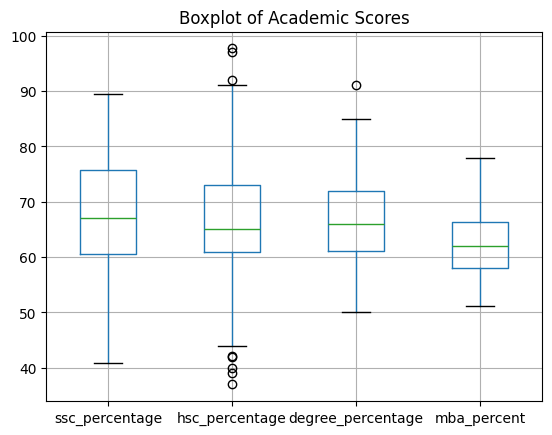

In [11]:
df.boxplot(column=[
    'ssc_percentage',
    'hsc_percentage',
    'degree_percentage',
    'mba_percent'
])
plt.title("Boxplot of Academic Scores")
plt.show()

In [12]:
z = np.abs(stats.zscore(df['mba_percent']))
print(df[z > 3])

Empty DataFrame
Columns: [gender, ssc_percentage, ssc_board, hsc_percentage, hsc_board, hsc_subject, degree_percentage, undergrad_degree, work_experience, emp_test_percentage, specialisation, mba_percent, status, salary]
Index: []


In [13]:
Q1 = df['hsc_percentage'].quantile(0.25)
Q3 = df['hsc_percentage'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 42.75
Upper Bound: 91.15


In [14]:
median = df['hsc_percentage'].median()

df['hsc_percentage'] = np.where(
    (df['hsc_percentage'] < lower) | (df['hsc_percentage'] > upper),
    median,
    df['hsc_percentage']
)

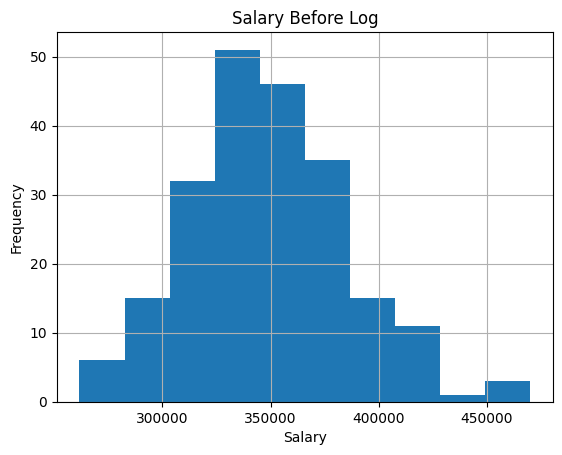

Skewness: 0.3625205776347454


In [15]:
df['salary'].hist()
plt.title("Salary Before Log")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

print("Skewness:", df['salary'].skew())

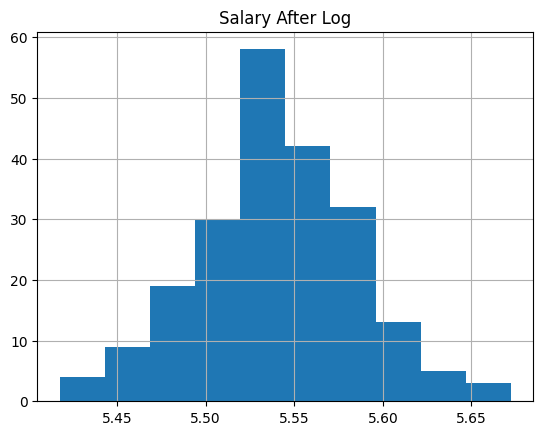

Skewness after log: 0.0028529132281144122


In [16]:
df['log_salary'] = np.log10(df['salary'])

df['log_salary'].hist()
plt.title("Salary After Log")
plt.show()

print("Skewness after log:", df['log_salary'].skew())

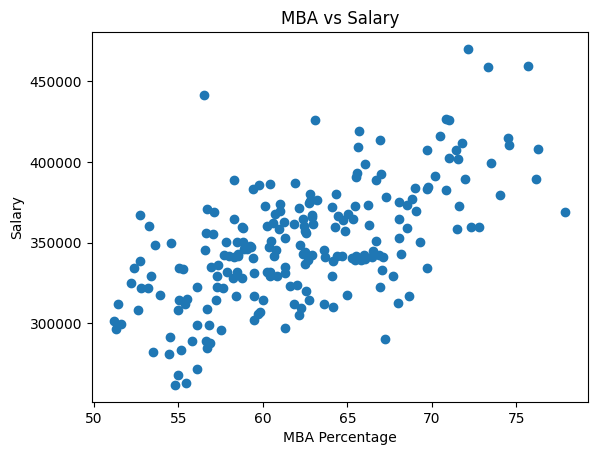

In [17]:
plt.scatter(df['mba_percent'], df['salary'])
plt.xlabel("MBA Percentage")
plt.ylabel("Salary")
plt.title("MBA vs Salary")
plt.show()

In [18]:
mad = (df['salary'] - df['salary'].mean()).abs().mean()
print("MAD:", mad)

print("Variance:", df['salary'].var())
print("Std Dev:", df['salary'].std())

print("Range:", df['salary'].max() - df['salary'].min())

MAD: 28503.476473769606
Variance: 1354113943.2042165
Std Dev: 36798.28723193807
Range: 208528.0
